# Stage 5 - Time Series Forecasting

## 04_arima.ipynb

#### Fits a time series forecast to one crime category from the South African crime statistics dataset and produces a projection with a confidence interval by:

- Loading the `sa_crime_clean` CSV from `data/processed/sa_crime_clean.csv`,      
- Extracting the crime category  `Contact` incidents and aggregating it to a national annual series,       
- Performing the Augmented Dickey-Fuller (ADF) test for investigating series stationarity,   
- Fitting an AutoRegressive Integrated Moving Average (ARIMA) model with `(p,d,q) = (1,1,1)`,     
- Producing a 3-year forecast with a 95% confidence interval (CI), 
- Producing a visualisation displaying the historical series, 3-year projection, and COVID-19 anomaly, and   
- Exporting and saving the produced chart to `reports/figures/` for the dashboarding and technical reporting stages in the project pipeline.

#### Data source: [Crime Statistics of South Africa (2011-2023)](https://www.kaggle.com/datasets/harutyunagababyan/crime-stats-of-south-africa-2011-2023)

-------------

Imports necessary libraries: `pandas` and `numpy` for data manipulation; `pyplot` and `mticker` from `matplotlib` for data visualisation; `os` for directory navigation; `warnings` for potential issue alerts; `adfuller` and `ARIMA` from `statsmodels` for stationary testing and model fitting:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt                            # chart rendering
import matplotlib.ticker as mticker                        # chart axis formatting
import warnings
import os

from statsmodels.tsa.stattools import adfuller                    
from statsmodels.tsa.arima.model import ARIMA

Ignores all potential warnings:

In [2]:
warnings.filterwarnings('ignore')

Navigates from notebook's location to project root, i.e. since notebooks live in `notebooks/`, goes up one level to reach project root:

In [3]:
dir_nb = os.getcwd()
project_root = os.path.dirname(dir_nb) 
os.chdir(project_root)                

print(os.getcwd())

C:\Users\Wits-User\Desktop\PROJECTS\sa-crime-statistics


Creates `reports/figures/` directory path if it does not exist:

In [4]:
os.makedirs('reports/figures/', exist_ok = True)

Ensures generated plots are rendered and displayed directly below code:

In [5]:
%matplotlib inline

Sets a consistent visual style for all produced charts:

In [6]:
plt.rcParams.update({
    'font.family'       :  'Arial',
    'figure.dpi'        :  300,
    'axes.spines.top'   :  False,     # hides top chart border lines 
    'axes.spines.right' :  False})    # hides right chart border lines

Provides option for global formatting of axis tick labels - ensures better readability: 

In [7]:
label_fmt = mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}')     # thousands annotation

Loads processed data from file:

In [8]:
crime_df = pd.read_csv('data/processed/sa_crime_clean.csv')

print('Crime statistics dataset read into dataframe!')

Crime statistics dataset read into dataframe!


Verifies dimensions, column labels, and crime categories of `crime_df` for confirmation purposes:

In [9]:
crime_df.shape

(756, 4)

In [10]:
crime_df.columns.tolist()

['province', 'crime_category', 'financial_year', 'incident_count']

In [11]:
crime_df['crime_category'].unique().tolist()

['Aggravated Robberies',
 'Contact',
 'Contact Related',
 'Police Action',
 'Other Serious',
 'Property Related',
 'Sexual Offences']

In order to build the time series, the selection of a category from `crime_df` is required. In this step, the `Contact` category is selected on account of its crime count being the largest and most stable over the 12-year window. As such, `Contact` is aggregated to national annual crime totals:

In [12]:
contact_df = (crime_df[crime_df['crime_category'] == 'Contact']
              .groupby('financial_year')['incident_count']
              .sum()
              .reset_index()
              .sort_values('financial_year'))

# builds the time series by setting years as row index and counts as values:
contact_ts = contact_df.set_index('financial_year')['incident_count']  

# confirms conversion of dataframe to series:
print(type(contact_ts))      # expected - <class 'pandas.core.series.Series'>

contact_ts

<class 'pandas.core.series.Series'>


financial_year
2011    615935
2012    608724
2013    611574
2014    616973
2015    623223
2016    608321
2017    601366
2018    617210
2019    621282
2020    535217
2021    607163
2022    653659
Name: incident_count, dtype: int64

A requirement of ARIMA is series stationarity. For this step, an ADF test is performed on series `contact_ts`. If the ADF p-value is greater than 0.05, then that indicates non-stationarity, and one round of differencing (`d = 1`) will be applied to `contact_ts` for ARIMA:

In [13]:
adf_test = adfuller(contact_ts)

print(f'ADF Statistic  :  {adf_test[0]:.4f}')        # formats ADF test statistic to four decimal places       
print(f'p-value        :  {adf_test[1]:.4f}')        # formats ADF p-value to four decimal places 

if adf_test[1] > 0.05:
    print('Time series is non-stationary - differencing required.')
else:
    print('Time series is stationary - no differencing required.')

ADF Statistic  :  0.5841
p-value        :  0.9872
Time series is non-stationary - differencing required.


In this step, an ARIMA model with parameters `(p,d,q) = (1,1,1)` is fitted to `contact_ts`. `ARIMA(1,1,1)` is selected due to `contact_ts` being a short annual series consisting only of 12 observations. Given the limited number of data points, the order `(p = 1, d = 1, q = 1)` is selected appropriately, as a more complex model would overfit:

In [14]:
arima_mdl = ARIMA(contact_ts, order = (1, 1, 1))            # d = 1 is standard approach when ADF test indicates non-stationarity
fitted_mdl = arima_mdl.fit()
fitted_mdl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:         incident_count   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -132.208
Date:                Mon, 18 May 2026   AIC                            270.415
Time:                        16:30:37   BIC                            271.609
Sample:                             0   HQIC                           269.663
                                 - 12                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1866      7.886      0.024      0.981     -15.270      15.643
ma.L1         -0.2068      7.920     -0.026      0.979     -15.729      15.316
sigma2      8.388e+08    3.2e-07   2.62e+15      0.000    8.39e+08    8.39e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.58   Jarque-Bera (JB):                 1.82
Prob(Q):                              0.45   Prob(JB):                         0.40
Heteroskedasticity (H):             110.52   Skew:                            -0.72
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.81e+32. Standard errors may be unstable.
"""

*Note - The fitted ARIMA model retains the COVID-19 anomaly in 2020, but is explicitly flagged. Consequently, the anomaly biases the forecast slightly downward and, as such, the projection should only be considered indicative and not precise.*  

Produces the 3-year out-of-sample forecast (with a 95% CI) using `fitted_mdl`, covering financial years 2023 to 2025:

In [15]:
forecast_years = 3         

ts_forecast = fitted_mdl.get_forecast(steps = forecast_years)   # returns point estimates and CIs

forecast_df = ts_forecast.summary_frame(alpha = 0.05)           # alpha value of 0.05 - 95% CI

# builds a forecast year index:
final_year       = contact_ts.index[-1]                         # expected: 2022                 
future_years     = list(range(final_year + 1, 
                              final_year + 1 + forecast_years)) # expected: ['2023', '2024', '2025']; range excludes endpoint, so endpoint - 1

# adds row index to forecast_df:
forecast_df.index = future_years

# displays average, upper and lower CI values for each projection year:
forecast_df[['mean', 'mean_ci_lower', 'mean_ci_upper']]

incident_count,mean,mean_ci_lower,mean_ci_upper
2023,652489.668714,595725.712994,709253.624434
2024,652271.510090,572803.644585,731739.375595
2025,652230.808891,555358.038867,749103.578915


Produces a visualisation of the forecast in the form of multi-line chart composed of 3 components - the historical `Contact` crime series, the forecast, and a connecting line that bridges the last historical data point to the first forecast point:

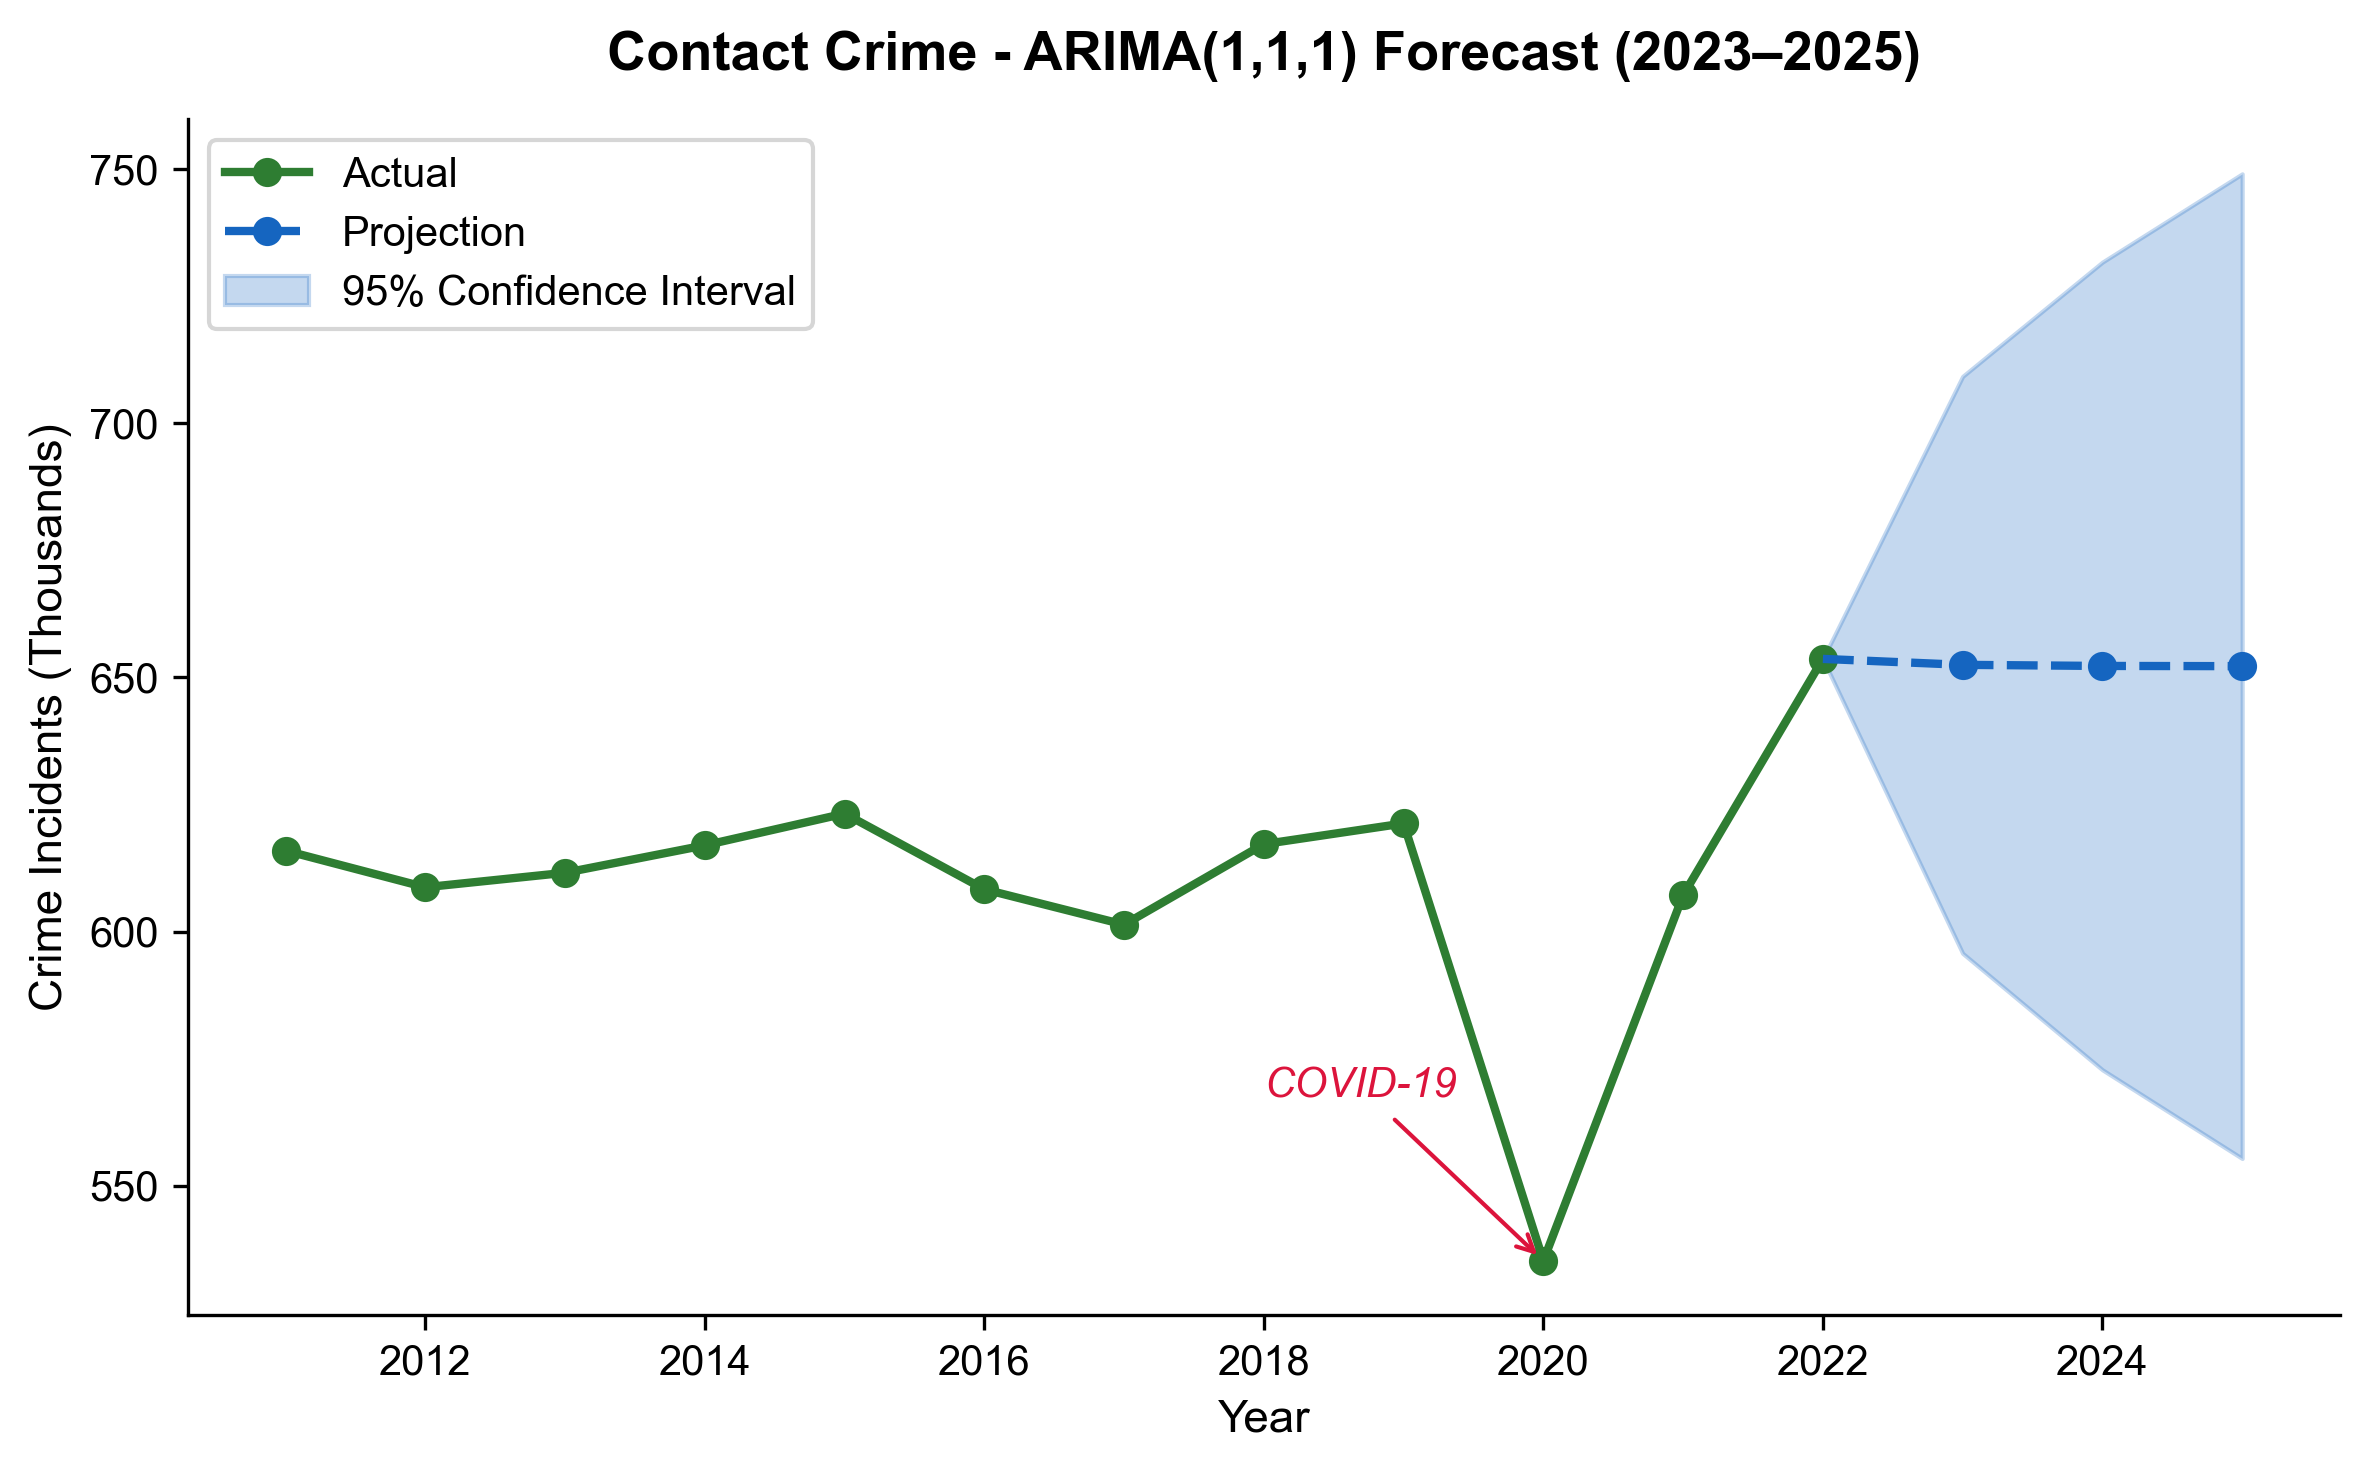

In [16]:
fig, ax = plt.subplots(figsize = (8,5))

# plots historical series:
ax.plot(contact_ts.index, 
        contact_ts.values, 
        marker = 'o', 
        color = '#2E7D32', 
        linewidth = 2, 
        label = 'Actual')

# plots forecast line:
ax.plot(forecast_df.index, 
        forecast_df['mean'], 
        marker = 'o', 
        linestyle = '--', 
        color = '#1565C0', 
        linewidth = 2, 
        label = 'Projection')

# inserts connecting line between historical series and forecast:
ax.plot([contact_ts.index[-1], forecast_df.index[0]],
        [contact_ts.values[-1], forecast_df['mean'].iloc[0]],
        color = '#1565C0',
        linewidth = 2,
        linestyle = '--')

# inserts 95% CI shading while prepending 2022 to x and y values:
ax.fill_between([contact_ts.index[-1]] + list(forecast_df.index),                  # concatenates 2022 to 'x' argument   
                [contact_ts.values[-1]] + list(forecast_df['mean_ci_lower']),      # concatenates count value for 2022 to y1
                [contact_ts.values[-1]] + list(forecast_df['mean_ci_upper']),      # and y2 argument
                alpha = 0.25, 
                color = '#1565C0', 
                label = '95% Confidence Interval')

# adds COVID annotation:
covid_count = contact_ts[2020]
ax.annotate('COVID-19',
            xy = (2020, covid_count),
            xytext = (2018, covid_count*1.06), 
            arrowprops = dict(arrowstyle = '->', color = '#DC143C'), 
            color = '#DC143C', 
            fontsize = 10, 
            style = 'italic')

ax.yaxis.set_major_formatter(label_fmt)                # calls global axis formatting option 
ax.set_xlabel('Year', fontsize = 11)
ax.set_ylabel('Crime Incidents (Thousands)', fontsize = 11)
ax.set_title('Contact Crime - ARIMA(1,1,1) Forecast (2023\u20132025)', fontsize = 13, fontweight = 'bold', pad = 12)
ax.legend()

plt.tight_layout()                                     # ensures better readability
plt.savefig('reports/figures/forecast_chart.png', dpi = 300, bbox_inches = 'tight')
plt.show()

The output of this notebook is as follows: one visualisation `forecast_chart.png` saved to `reports/figures/`. This singular output is ready for use in the dashboarding and technical reporting stages in the project pipeline.

##### Model Limitations

- Fundamental: As the annual series `contact_ts` is short and has a limited sample size of 12 data points, any forecast produced from it should be treated as purely directional regardless of any other factors, i.e. behaviours and trends inferred from the forecast can only be considered indicative and not precise. Additionally, ARIMA models tend to require a larger sample size to produce reliable estimates, so with the 12 data points, all parameter estimates hold significant uncertainty.

- Specific: The COVID-19 anomaly in 2020 serves as an outlier that is representative of reduced public movement during lockdown, and, as a result, introduces a slight downward bias into the model's behaviour. This provides further evidence in favour of treating the projection as indicative and not precise.